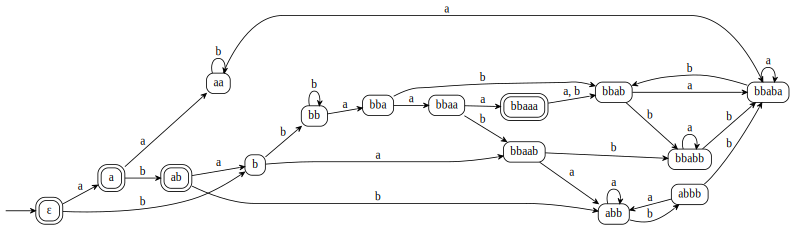

In [6]:
from pathlib import Path

from sproutcex.random_testing import load_automata

automata = load_automata(automata_count=10000, seed=43)

display(automata[0])

In [ ]:
import string

from sproutcex.graph_functions import generate_wdba, Automaton
from sproutcex.random_testing import reciprocal_distribution, sproutcex_silent

alphabet_low, alphabet_high = 2, 4
state_low, state_high = 4, 30
automaton_count = 20
full_alphabet = string.ascii_lowercase
seed = 42

automata = []

for _ in range(automaton_count):
    alphabet_size = reciprocal_distribution(alphabet_low, alphabet_high)
    state_count = reciprocal_distribution(state_low, round(
        state_high * alphabet_low / alphabet_size))
    automaton = generate_wdba(state_count, full_alphabet[:alphabet_size])
    automata.append(automaton)

for automaton in automata:
    print(f"{len(automaton)=}")
    reduced_automaton, query_count = sproutcex_silent(automaton)
    automaton_alphabet = automaton.get_alphabet()
    alphabet_size = len(automaton_alphabet)
    automaton_size = len(reduced_automaton)
    print(
        f"{automaton_size=} {alphabet_size=} {query_count=} reference_count={alphabet_size * automaton_size ** 2}")